## **HR Employee Attrition Prediction**

##### **About**
HR Employee Attrition Prediction is a machine learning project that analyzes employee data to predict whether an employee is likely to leave an organization. By examining factors such as job role, satisfaction level, income, and years at the company, the model identifies patterns associated with employee turnover.

The goal of the project is to support HR teams in making data-driven decisions, improving employee retention strategies, and reducing organizational costs related to attrition.

#### **Loading of the Dataset**

The dataset used for this project was obtained from Kaggle, specifically the **IBM HR Analytics Employee Attrition & Performance** dataset. It contains structured employee records including demographic information, job-related features, and an attrition indicator. The dataset was loaded into the project environment using Python (Pandas) for further preprocessing, analysis, and model development.

**MOUNTING DRIVE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


***Get Drive Path***
###### I imported python os library to grant me access to my drive where i could locate the dataset

In [ ]:
import os
path = "/content/drive/MyDrive/"
# os.listdir(path)
datafile = "hr_employee_attrition.csv"

***Importing neccessary libraries***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import math

**Loading dataset**

In [ ]:
df = pd.read_csv(f'{path}{datafile}')
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**DESCRIPTIVE STATISTICS OF THE DATA**
## `df.info()`

### What It Does
`df.info()` provides a **summary of the dataset structure**.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## **df.describe()**

`df.describe()` is used to generate a statistical summary of all numerical columns in a dataset.

It displays:
- Count (number of values)
- Mean (average)
- Standard deviation
- Minimum and maximum values
- 25th, 50th (median), and 75th percentiles

It helps in understanding data distribution, detecting outliers, and preparing features for scaling before building a machine learning model.

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


***DATA WRANGLING AND CLEANING***
---
Data Wrangling and Cleaning is the process of transforming raw data into a clean, structured, and usable format before analysis or machine learning.
For the IBM HR Attrition dataset, the following steps were performed:
- Handling Missing Values
- Checking Duplicates
- Checking for Outliers
- Correcting wrong Data Format

---

#### **1.*CHECKING FOR MISSING VALUES***
---
`df.isna().sum()` is used to check if there are missing values and if there are sum all the missing values for each column.

From below there is no missing values in the dataset

In [ ]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


#### **2.*CHECKING FOR Duplicates***

`df.is_duplicated().sum()` is used to check if there are duplicates in the dataset and if there are sum all the duplicates values.

From below there are no duplicates values in the dataset

In [ ]:
df.duplicated().sum()

0

#### **OUTLIER DETECTION**

Outliers are extreme values that differ significantly from other observations.  
Detecting outliers is important because they can negatively affect machine learning models.

---

##### **Using Statistical Summary**

First, we examine the spread of numerical features:

```python
df.describe()
If the difference between the 75th percentile and maximum value is very large,
it may indicate potential outliers.

`df.select_dtypes(include=['number']).columns` selects all numerical columns from the dataset.

`df[numerical_cols].describe()` then generates a statistical summary of those numerical features, including count, mean, standard deviation, minimum, maximum, and quartiles.

This helps in understanding data distribution, detecting outliers, and preparing the data for scaling before modeling.

In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns
df[numerical_cols].describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


#### **Using Boxplots (Visual Method)**

Boxplots are one of the best ways to detect outliers visually.
#
This loop iterates through each numerical column in the dataset. For each column, it creates a new figure with a specified size (10 by 5).  
`sns.boxplot()` is used to draw a boxplot for that numerical feature.  The title is dynamically set to show the name of the current column.  
`plt.show()` displays the boxplot, helping to visually detect outliers.
#
**Points appearing outside the whiskers represent potential outliers.**

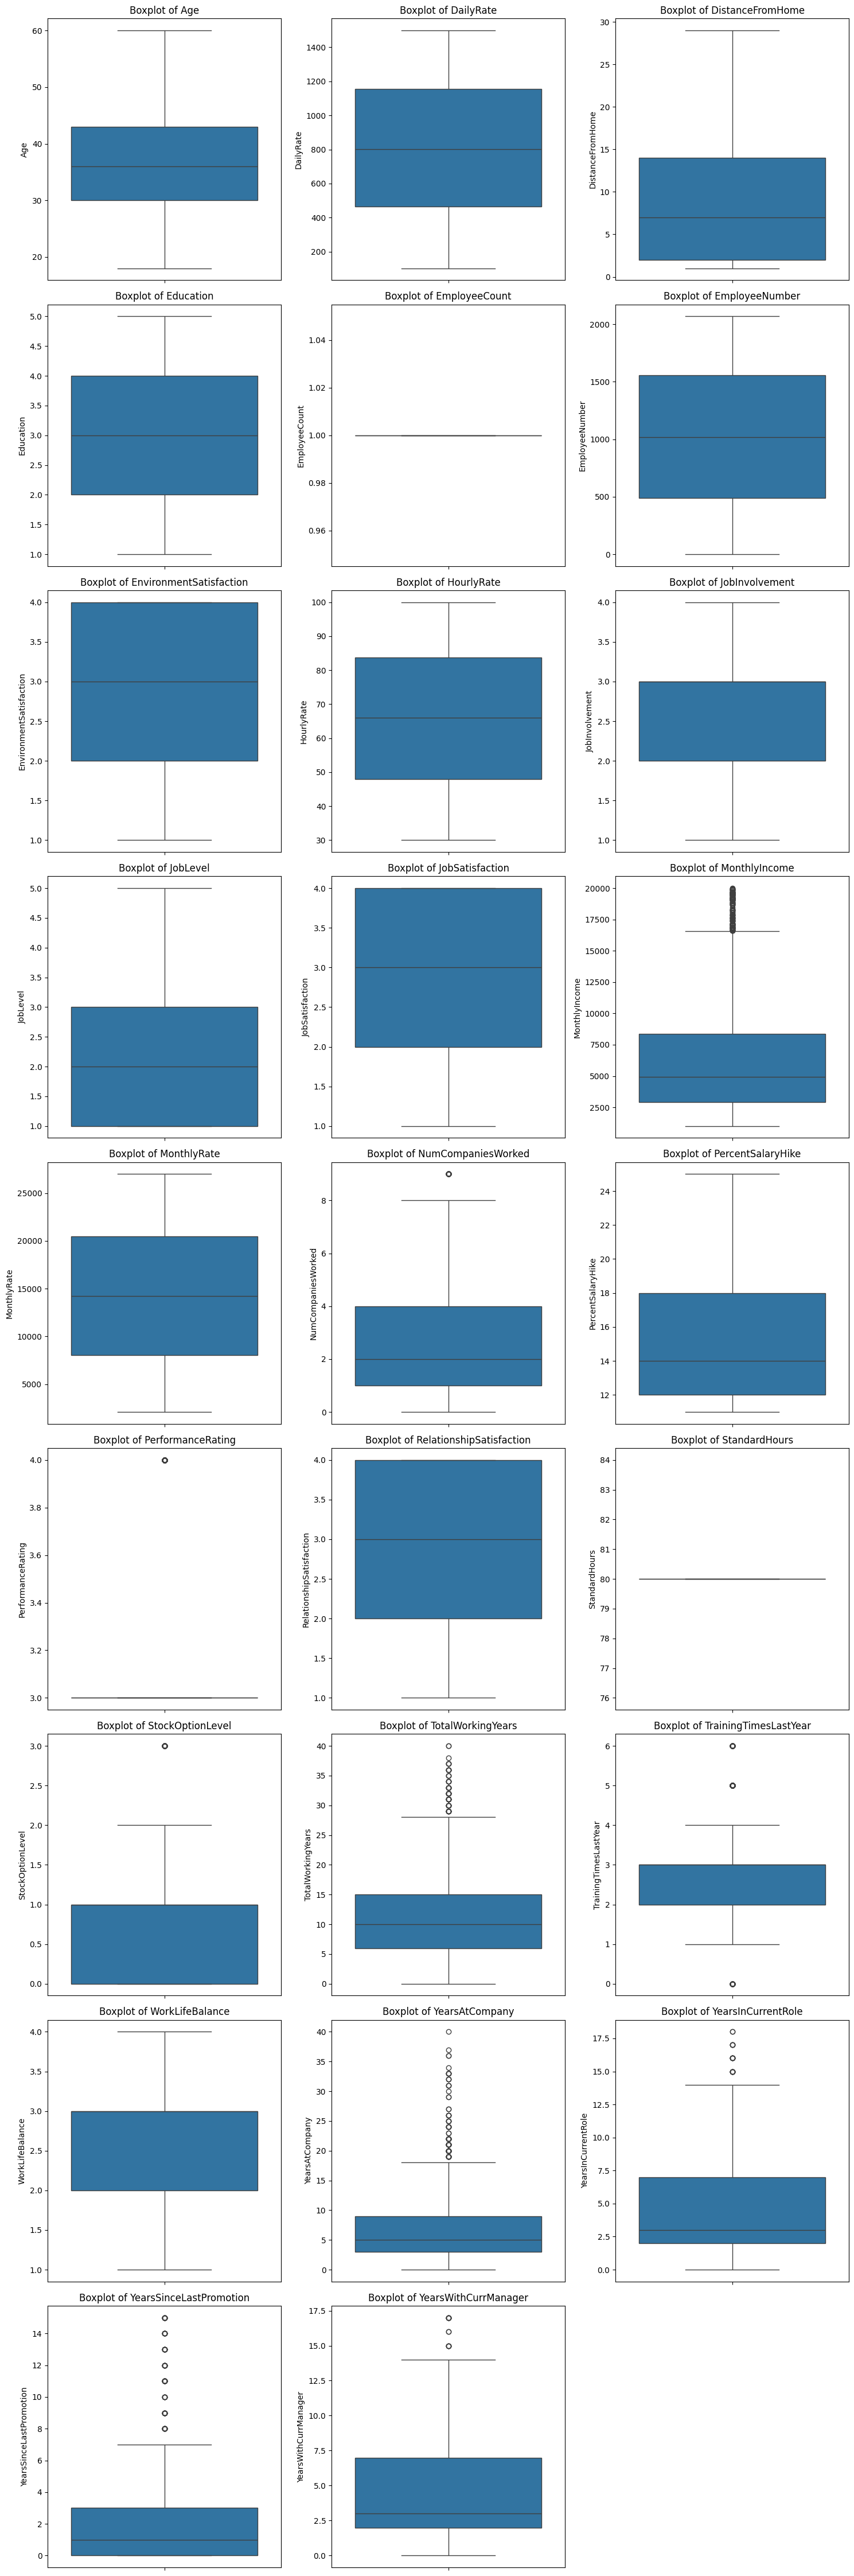

In [ ]:
# Number of columns per row
cols_per_row = 3

# Total numerical columns
num_cols = len(numerical_cols)

# Number of rows needed
rows = math.ceil(num_cols / cols_per_row)

# Create subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(5*cols_per_row, 5*rows))

# Flatten axes for easy iteration (in case rows*cols_per_row > num_cols)
axes = axes.flatten()

# Plot each numerical column
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])  # Use y= for vertical orientation
    axes[i].set_title(f"Boxplot of {col}")

# Hide any empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# HANDLING OUTLIERS
# - First I will remove all columns I dont need in my analysis

In [ ]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # filter outlier
    upper_outliers = df[df[col] > upper_bound]
    lower_outliers = df[df[col] < lower_bound]
    # the outliers could be valid values, rather than dropping it i will cap the outliers
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

cap_outliers(df, 'MonthlyIncome')
cap_outliers(df, 'TotalWorkingYears')
cap_outliers(df, 'YearsAtCompany')
cap_outliers(df, 'YearsSinceLastPromotion')
cap_outliers(df, 'YearsWithCurrManager')


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8.0,0,1,6,4,0.0,5.0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10.0,3,3,10,7,1.0,7.0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7.0,3,3,0,0,0.0,0.0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8.0,3,3,8,7,3.0,0.0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6.0,3,3,2,2,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17.0,3,3,5,2,0.0,3.0
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9.0,5,3,7,7,1.0,7.0
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6.0,0,3,6,2,0.0,3.0
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17.0,3,2,9,6,0.0,8.0


###**ANALYSIS AND INSIGHTS**


## 1. Attrition Distribution
Shows the proportion of employees who left vs. stayed. Helps check class imbalance. Usually, more employees stay than leave.

This shows the number of employees who left vs those who stayed. **237 which make 16.12 by propotion** Employees left while **1233 making 83.87 by propotion** who Stayed

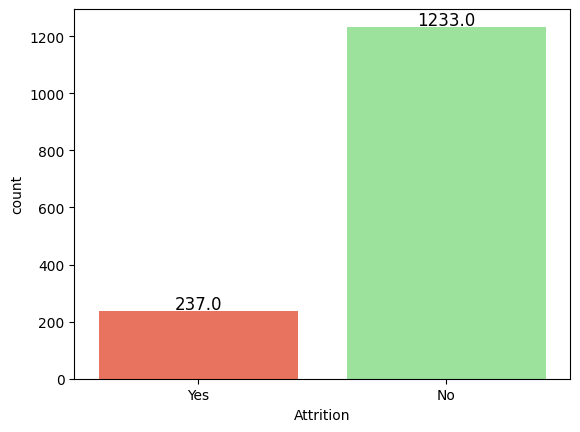

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [ ]:
AttritionPropotion = df['Attrition'].value_counts(normalize=True) * 100
ax= sns.countplot(x='Attrition', data=df, palette=['tomato','lightgreen'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()
print(AttritionPropotion)

### **Analysis of Attrition by Department**

The bar chart above displays the distribution of attrition across different departments within the company. Each bar represents a department, with segments colored to differentiate between employees who stayed ('No') and those who left ('Yes').

**Key observations from this chart can include:**

*   **Departments with High Attrition:** Identify departments where the 'Yes' (attrition) segment is proportionally larger, or where the absolute number of employees leaving is high.
*   **Departments with Low Attrition:** Observe departments with a predominantly 'No' (stayed) segment, indicating better retention.
*   **Overall Department Representation:** Understand the number of employees in each department, which provides context for attrition numbers.

This visualization helps pinpoint specific departments that might be struggling with employee retention, guiding HR to focus their strategies more effectively.

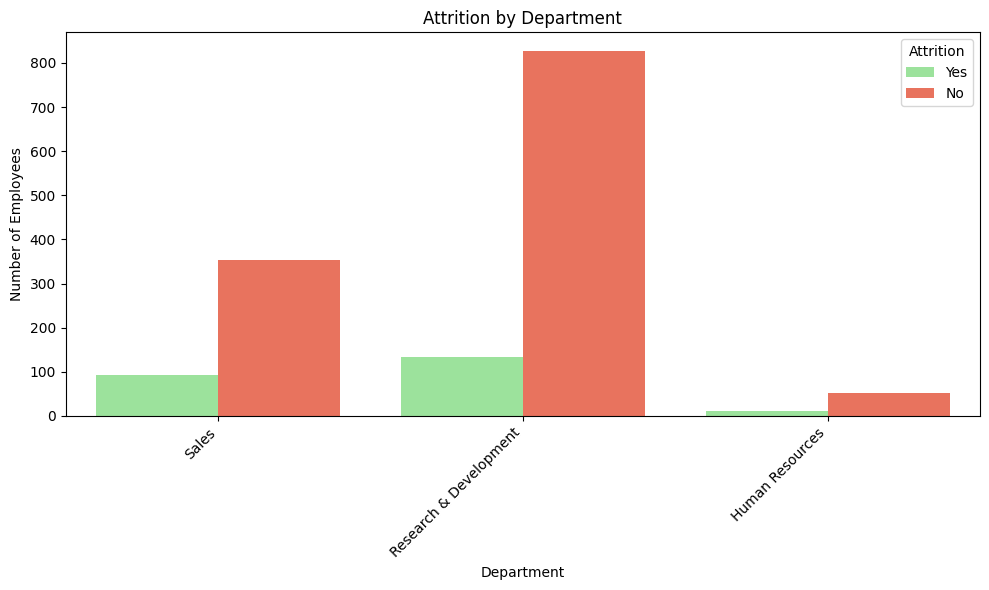

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Department', hue='Attrition', data=df, palette=['lightgreen', 'tomato'])
plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Gender Distribution

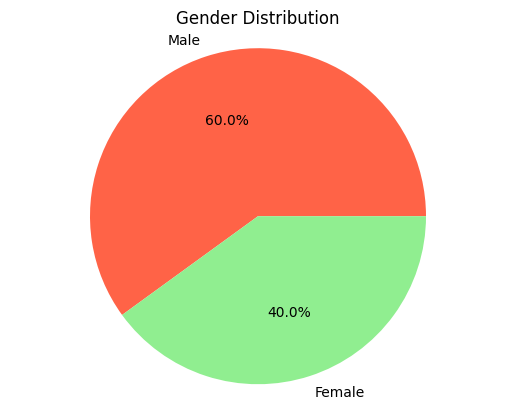

In [ ]:
GenderDistrib = df['Gender'].value_counts(normalize=True) * 100
plt.pie(GenderDistrib, labels=GenderDistrib.index, autopct='%1.1f%%', colors=['tomato', 'lightgreen'])
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Gender Distribution')
plt.show()

### **Analysis of Attrition by Job Role**

The bar chart above illustrates the distribution of attrition across various job roles within the company. Each bar represents a job role, with segments colored to indicate employees who stayed ('No') and those who left ('Yes').

**Key observations from this chart can include:**

*   **Roles with High Attrition:** Identify job roles where the 'Yes' (attrition) segment is proportionally larger, or where the absolute number of employees leaving is high.
*   **Roles with Low Attrition:** Observe roles with a predominantly 'No' (stayed) segment, indicating better retention.
*   **Overall Role Representation:** Understand the number of employees in each job role, which provides context for attrition numbers.

This visualization helps pinpoint specific departments or job functions that might be struggling with employee retention, guiding HR to focus their strategies more effectively.

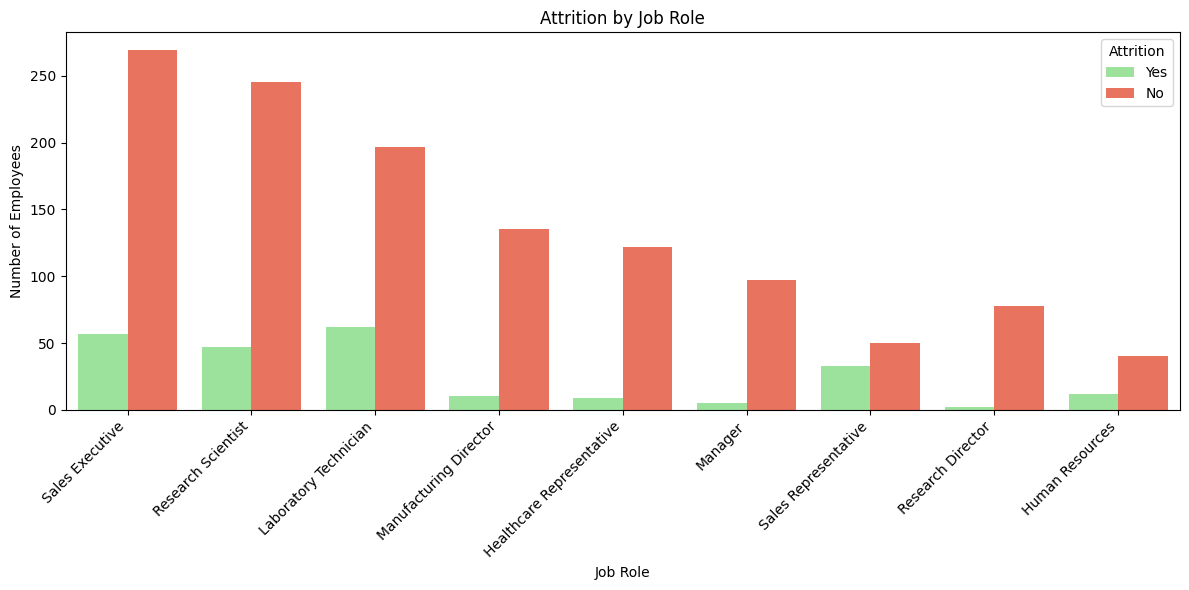

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='JobRole', hue='Attrition', data=df, palette=['lightgreen', 'tomato'])
plt.title('Attrition by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Analysis of Attrition Breakdown by Gender and Age Band**

This visualization presents a detailed breakdown of employee attrition, segmenting it by both **Gender** and **Age Band**. Each sub-plot represents a gender, and within each, bars show the number of employees who stayed ('No') or left ('Yes') for various age groups.

**Key observations from this chart can include:**

*   **Age Groups with High Attrition:** Identify specific age bands that show a proportionally higher rate of employees leaving for either gender.
*   **Gender-Specific Trends:** Observe if there are differences in attrition patterns between male and female employees across different age bands.
*   **Overall Employee Distribution:** Understand the age distribution of the workforce within each gender and how it relates to attrition.

This granular analysis can help HR develop targeted retention strategies, addressing the specific concerns or needs of different gender-age cohorts that are more susceptible to attrition.

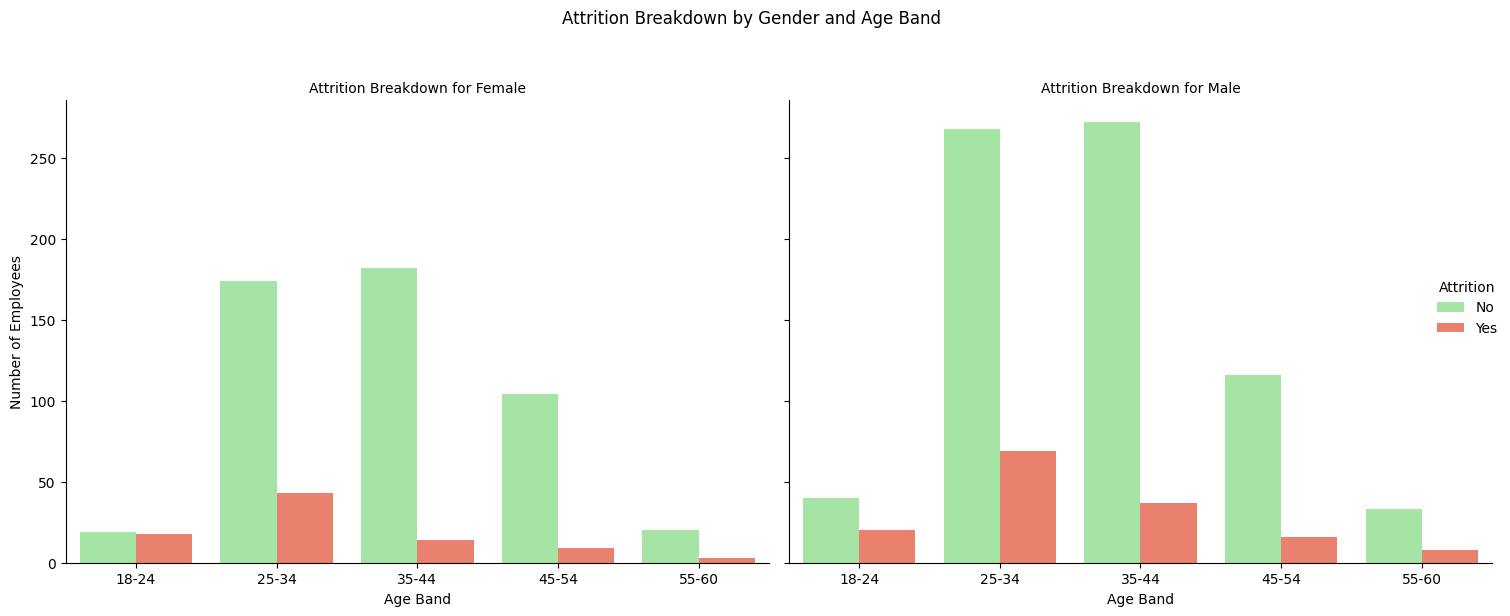

In [ ]:
# Create Age-Bands
bins = [18, 25, 35, 45, 55, 60]
labels = ['18-24', '25-34', '35-44', '45-54', '55-60']
df['Age_Band'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Use sns.catplot for faceted plots with 'col' parameter
g = sns.catplot(data=df, x='Age_Band', hue='Attrition', col='Gender', kind='count',
                height=6, aspect=1.2, palette=['lightgreen', 'tomato'],
                hue_order=['No', 'Yes'], alpha=0.9)

g.set_axis_labels('Age Band', 'Number of Employees')
g.set_titles('Attrition Breakdown for {col_name}')
g.fig.suptitle('Attrition Breakdown by Gender and Age Band', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# Task
Perform feature engineering on the `df` DataFrame by: dropping 'EmployeeCount', 'StandardHours', 'EmployeeNumber', and 'Over18' columns; encoding the 'Attrition' column to numerical format (Yes=1, No=0); one-hot encoding all remaining categorical features including 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', and 'OverTime'; and finally, scaling all numerical features using `StandardScaler` to prepare the dataset for model building.

## Identify and Drop Unnecessary Columns

### Subtask:
Identify and remove columns that are constant or serve as identifiers, such as 'EmployeeCount', 'StandardHours', 'EmployeeNumber', and 'Over18', as they won't contribute to the predictive power of the model.


**Excluding Unnecessary Columns**:
To achieve the subtask, I will exclude the specified columns ('EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18') from the DataFrame `df` as they are identified as unnecessary for model prediction.
I will only maintain key columns for my features



In [ ]:
df['OverTime'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

In [ ]:
X = df[['JobSatisfaction', 'OverTime', 'MonthlyIncome', 'YearsAtCompany',  'WorkLifeBalance',
       'EnvironmentSatisfaction',  'JobRole', 'Department','Age','DistanceFromHome','TotalWorkingYears',
        'YearsSinceLastPromotion','YearsWithCurrManager']]

**Maping Attrition Column to Numerical Format**:
The previous subtask of excluding unnecessary columns has been completed. Now, I will proceed to encode the 'Attrition' column into a numerical format, mapping 'Yes' to 1 and 'No' to 0, which is necessary for model training.



In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
y = df['Attrition']
print("Attrition column encoded successfully:")
print(y.value_counts())

Attrition column encoded successfully:
Attrition
0    1233
1     237
Name: count, dtype: int64


**One-Hot Encoding**:
The 'Attrition' column has been successfully encoded. Now, I will proceed to one-hot encode all remaining categorical features in the DataFrame to convert them into a numerical format suitable for machine learning models.



In [ ]:
categorical_labels = ['JobRole', 'Department']
df_encoded = pd.get_dummies(X, columns=categorical_labels, drop_first=True)
df_encoded = df_encoded.astype(int)

In [ ]:
X = df_encoded

Feature Engineering

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Scaling**

In [ ]:
numerical_cols_to_scale = ['JobSatisfaction', 'MonthlyIncome', 'YearsAtCompany',  'WorkLifeBalance',
       'EnvironmentSatisfaction', 'Age','DistanceFromHome','TotalWorkingYears',
        'YearsSinceLastPromotion','YearsWithCurrManager']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

Building Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Logistic Regression

In [ ]:
modelL = LogisticRegression()
modelL.fit(X_train, y_train)
y_pred = modelL.predict(X_test)

In [ ]:
print(f'Accuracy Score {accuracy_score(y_test, y_pred)}')
print(f'Classification Report {classification_report(y_test, y_pred)}')
print(f'Confusion Matrix {confusion_matrix(y_test, y_pred)}')

Accuracy Score 0.8707482993197279
Classification Report               precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.55      0.15      0.24        39

    accuracy                           0.87       294
   macro avg       0.71      0.57      0.58       294
weighted avg       0.84      0.87      0.84       294

Confusion Matrix [[250   5]
 [ 33   6]]


**Decision Tree**

In [ ]:
modelDT = DecisionTreeClassifier()
modelDT.fit(X_train, y_train)
y_pred = modelDT.predict(X_test)

In [ ]:
print(f'Accuracy Score {accuracy_score(y_test, y_pred)}')
print(f'Classification Report {classification_report(y_test, y_pred)}')
print(f'Confusion Matrix {confusion_matrix(y_test, y_pred)}')

Accuracy Score 0.7789115646258503
Classification Report               precision    recall  f1-score   support

           0       0.88      0.86      0.87       255
           1       0.22      0.26      0.24        39

    accuracy                           0.78       294
   macro avg       0.55      0.56      0.55       294
weighted avg       0.79      0.78      0.79       294

Confusion Matrix [[219  36]
 [ 29  10]]


**Random Forest**

In [ ]:
modelRF = RandomForestClassifier()
modelRF.fit(X_train, y_train)
y_pred = modelRF.predict(X_test)

In [ ]:
print(f'Accuracy Score {accuracy_score(y_test, y_pred)}')
print(f'Classification Report {classification_report(y_test, y_pred)}')
print(f'Confusion Matrix {confusion_matrix(y_test, y_pred)}')

Accuracy Score 0.8775510204081632
Classification Report               precision    recall  f1-score   support

           0       0.89      0.98      0.93       255
           1       0.64      0.18      0.28        39

    accuracy                           0.88       294
   macro avg       0.76      0.58      0.61       294
weighted avg       0.85      0.88      0.85       294

Confusion Matrix [[251   4]
 [ 32   7]]


**Using ANN**

In [ ]:
modelsANN =  Sequential()
modelsANN.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
modelsANN.add(Dense(32, activation='relu'))
modelsANN.add(Dense(1, activation='sigmoid'))
modelsANN.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modelsANN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modelsANN.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8340 - loss: 0.4960 - val_accuracy: 0.7966 - val_loss: 0.4912
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8404 - loss: 0.4254 - val_accuracy: 0.7966 - val_loss: 0.4670
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8415 - loss: 0.3996 - val_accuracy: 0.8008 - val_loss: 0.4568
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8415 - loss: 0.3843 - val_accuracy: 0.8093 - val_loss: 0.4465
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8596 - loss: 0.3707 - val_accuracy: 0.8008 - val_loss: 0.4338
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8574 - loss: 0.3568 - val_accuracy: 0.8008 - val_loss: 0.4302
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8606 - loss: 0.3456 - val_accuracy: 0.8008 - val_loss: 0.4224
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8702 - loss: 0.3377 - val_accuracy: 0.8178 - val_los

In [ ]:
loss, accuracy =modelsANN.evaluate(X_test, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8503 - loss: 0.4418 


***FIXING CLASS IMBALANCE WITH XGBOOST***
In the IBM HR Dataset, The Attrition Yes is much smaller than No, so the models tend to predict No too often

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Before:", y_train.value_counts())
print("After:", y_train_resampled.value_counts())

Before: Attrition
0    978
1    198
Name: count, dtype: int64
After: Attrition
0    978
1    978
Name: count, dtype: int64


From the above, both classes are now balance, now lets train

#### **TRAIN an XGBoost Model**


In [ ]:
# pip install xgboost

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    random_state=42
)
xgb_model.fit(X_train_resampled, y_train_resampled)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=None, num_parallel_tree=None, ...)

**Make Prediction**

In [ ]:
y_pred = xgb_model.predict(X_test)


In [ ]:
# from sklearn.model_selection import cross_val_score
# scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
# print(scores.mean())

**Evaluate the Model**

In [ ]:
print(f'Accuracy Score {accuracy_score(y_test, y_pred)}')
print(f'Classification Report {classification_report(y_test, y_pred)}')
print(f'Confusion Matrix {confusion_matrix(y_test, y_pred)}')

Accuracy Score 0.8639455782312925
Classification Report               precision    recall  f1-score   support

           0       0.90      0.95      0.92       255
           1       0.48      0.31      0.38        39

    accuracy                           0.86       294
   macro avg       0.69      0.63      0.65       294
weighted avg       0.84      0.86      0.85       294

Confusion Matrix [[242  13]
 [ 27  12]]


**Features Importance**

In [ ]:
importance = pd.DataFrame({
    'Features':X.columns,
    'Importance':xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importance)


                             Features  Importance
11            JobRole_Human Resources    0.110422
13                    JobRole_Manager    0.084169
19  Department_Research & Development    0.077072
10               YearsWithCurrManager    0.071099
1                            OverTime    0.059400
0                     JobSatisfaction    0.054142
5             EnvironmentSatisfaction    0.054083
4                     WorkLifeBalance    0.050039
20                   Department_Sales    0.046249
14     JobRole_Manufacturing Director    0.045459
9             YearsSinceLastPromotion    0.045074
3                      YearsAtCompany    0.040361
17            JobRole_Sales Executive    0.039506
6                                 Age    0.035525
16         JobRole_Research Scientist    0.035040
12      JobRole_Laboratory Technician    0.028548
2                       MonthlyIncome    0.027994
8                   TotalWorkingYears    0.027482
7                    DistanceFromHome    0.026904


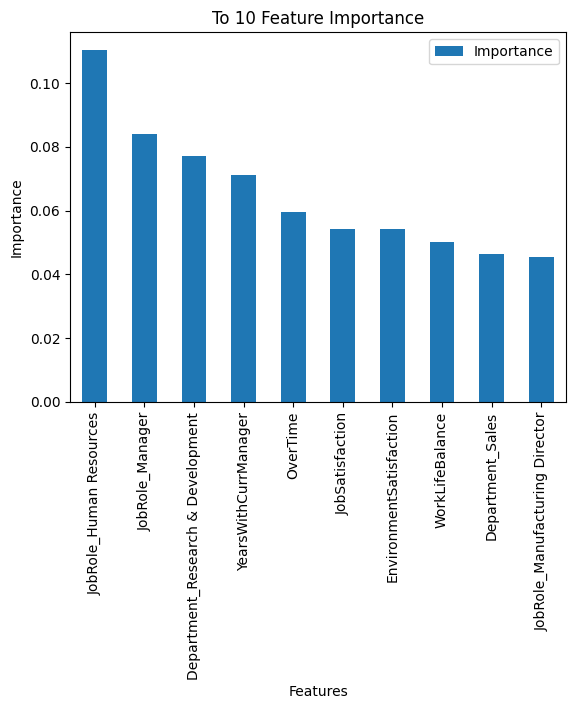

In [ ]:
importance.head(10).plot(x='Features', y='Importance',kind='bar', legend=True)
plt.title('To 10 Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()